In [ ]:
#Basic important imports
import os
import numpy as np
import pandas as pd
from pathlib import Path

#For image processing
import cv2
from PIL import Image

#For training/testing model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

import random

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

#Keras imports needed for the CNN
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential #for defining CNN
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, SpatialDropout2D, GlobalAveragePooling2D
) #Important components for CNN
from tensorflow.keras.regularizers import l2 #

import tensorflow.keras as keras

In [ ]:
#Connecting to google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from huggingface_hub import login #https://huggingface.co/spaces/jphappy/Traffic_light_detection
login("API_Key") #authenticating colab session to push files to hugging face via API key

In [ ]:
!unzip "/content/drive/MyDrive/AI_final_project/archive_(3)" -d "/content/lisa_dataset" #Unzipping the kaggle data into something the model can use

Archive:  /content/drive/MyDrive/AI_final_project/archive_(3).zip
replace /content/lisa_dataset/cropped_lisa_1/train_1/go/ds1_pic10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#Smaller subset(for testing and debugging)

import shutil
import random
source_root = "/content/lisa_dataset/cropped_lisa_1/train_1"
target_root = "/content/lisa_subset/train"

# Max number of examples per class
MAX_PER_CLASS = 100

# Target classes for the traffic light signals.
classes = [
    "go",
    "goForward",
    "goLeft",
    "stop",
    "stopLeft",
    "warning",
    "warningLeft"
]

for cls in classes:
    source_dir = os.path.join(source_root, cls)
    target_dir = os.path.join(target_root, cls)

    os.makedirs(target_dir, exist_ok=True)

    images = os.listdir(source_dir)
    random.shuffle(images)

    selected = images[:MAX_PER_CLASS]

    for img in selected:
        shutil.copy(
            os.path.join(source_dir, img),
            os.path.join(target_dir, img)
        )


In [ ]:
#Setting up with all data

MAX_PER_CLASS = 5000
TARGET_SIZE   = (64, 64)
BATCH_SIZE    = 32
TRAIN_DIR     = "/content/lisa_dataset/cropped_lisa_1/train_1"
VAL_DIR       = "/content/lisa_dataset/cropped_lisa_1/val_1"

# Only rescale here — augmentation is handled by ImageDataGenerator below
X_train_list, y_train_list = [], []
class_names = sorted(os.listdir(TRAIN_DIR))
class_index = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(images)
    images = images[:MAX_PER_CLASS]
    for fname in images:
        fpath = os.path.join(class_dir, fname)
        try:
            img = load_img(fpath, target_size=TARGET_SIZE)
            X_train_list.append(img_to_array(img))
            y_train_list.append(class_index[class_name])
        except Exception:
            pass

#Define the train arrays using numpy
X_train = np.array(X_train_list, dtype='float32')
y_train = np.array(y_train_list, dtype='int32')

print("Training class distribution after capping:")
for name, idx in class_index.items():
    count = np.sum(y_train == idx)
    print(f"  {name} (class {idx}): {count} samples")


Training class distribution after cap:
  go (class 0): 5000 samples
  goForward (class 1): 184 samples
  goLeft (class 2): 1030 samples
  stop (class 3): 5000 samples
  stopLeft (class 4): 2845 samples
  warning (class 5): 985 samples
  warningLeft (class 6): 48 samples


In [ ]:
#Data augmentation, changes to rotation, width and height, flips, zooms, and brightness
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255) #no need for augmentation for validation

train_ds = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation and train test split
full_val_ds = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 3737 images belonging to 7 classes.


In [ ]:
# Verify class order matches training
print("\nVal class indices:", full_val_ds.class_indices)
print("Train class index:", class_index)
assert full_val_ds.class_indices == class_index, \
    "Class order mismatch between train and val! Check your directories."

X_val_all, y_val_all = zip(*[full_val_ds[i] for i in range(len(full_val_ds))])
X_val_all = np.concatenate(X_val_all)
y_val_all = np.concatenate(y_val_all)

X_val, X_test, y_val, y_test = train_test_split(
    X_val_all, y_val_all,
    test_size=0.5,
    random_state=42,
    stratify=y_val_all
)

val_ds = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_ds = val_datagen.flow(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain : {len(X_train)} samples (capped at {MAX_PER_CLASS}/class)")
print(f"Val   : {len(X_val)} samples")
print(f"Test  : {len(X_test)} samples")


Val class indices: {'go': 0, 'goForward': 1, 'goLeft': 2, 'stop': 3, 'stopLeft': 4, 'warning': 5, 'warningLeft': 6}
Train class index: {'go': 0, 'goForward': 1, 'goLeft': 2, 'stop': 3, 'stopLeft': 4, 'warning': 5, 'warningLeft': 6}

Train : 15092 samples (capped at 5000/class)
Val   : 1868 samples
Test  : 1869 samples


In [ ]:
# Getting class weights to address the training data imbalance.
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights = np.sqrt(np.sqrt(weights))
weights = weights / weights.min()
class_weight_dict = dict(enumerate(weights))
print("\nSoftened weights:", class_weight_dict)


Softened weights: {0: np.float64(1.0), 1: np.float64(2.283168927483656), 2: np.float64(1.4843393298690695), 3: np.float64(1.0), 4: np.float64(1.151388621868892), 5: np.float64(1.5010095087295965), 6: np.float64(3.194715521231362)}


In [ ]:
#defining CNN model
model = Sequential([
    # First block
    # Take the input: 64x64 pixel image with 3 channels for RGB.
    # Create a convolution block with 32 filters where each filter looks at the image in 3x3 regions.
    # The RELU activation function is then applied on the feature map of the filters.
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    BatchNormalization(),
    # pooling layer of size 2x2
    MaxPooling2D(pool_size=(2, 2)),
    # dropout of 0.25 is introduced, in order to prevent overfitting
    Dropout(0.25),

    # 2nd block where 3x3 regions is applied, but this time there are 64 filters
    # so that complex features such as colors and edges can be learned.
    # The activation function and pooling are identical to the previous block.
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    # dropout of 0.25 is introduced, in order to prevent overfitting
    Dropout(0.25),

    # The data is flattened and put into a dense layer of 128 neurons.
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    # The final output layer consists of 7 neurons with softamax activation functions.
    Dense(7, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#loading previous model (if needed)
model = keras.models.load_model("/content/drive/MyDrive/AI_final_project/traffic_light_model.keras")

In [ ]:
# Training
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)

Epoch 1/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 198s 409ms/step - accuracy: 0.7616 - loss: 1.3817 - val_accuracy: 0.3672 - val_loss: 19.8466
Epoch 2/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 196s 416ms/step - accuracy: 0.8140 - loss: 1.0089 - val_accuracy: 0.0289 - val_loss: 9.1258
Epoch 3/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 197s 416ms/step - accuracy: 0.8475 - loss: 0.8778 - val_accuracy: 0.3672 - val_loss: 7.4673
Epoch 4/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 205s 433ms/step - accuracy: 0.8554 - loss: 0.8073 - val_accuracy: 0.4754 - val_loss: 2.6930
Epoch 5/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 201s 425ms/step - accuracy: 0.8718 - loss: 0.7610 - val_accuracy: 0.3672 - val_loss: 5.0400
Epoch 6/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 196s 415ms/step - accuracy: 0.8696 - loss: 0.7979 - val_accuracy: 0.3672 - val_loss: 12.9077
Epoch 7/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 199s 422ms/step - accuracy: 0.8831 - loss: 0.7574 - val_accuracy: 0.4775 - val_loss: 2.3968
Epoch 8/20
472/472 ━━━━━━━━━━━━━━━━━━━━ 196s 415ms/step - accuracy: 0.8911

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,353,495 (24.24 MB)

 Trainable params: 2,117,767 (8.08 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 4,235,536 (16.16 MB)

59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step

Classification Report:
              precision    recall  f1-score   support

          go       0.97      0.99      0.98       686
   goForward       0.90      0.90      0.90        10
      goLeft       0.88      0.65      0.75        55
        stop       0.88      0.97      0.92       889
    stopLeft       0.64      0.31      0.41       173
     warning       1.00      1.00      1.00        54
 warningLeft       1.00      1.00      1.00         2

    accuracy                           0.91      1869
   macro avg       0.90      0.83      0.85      1869
weighted avg       0.89      0.91      0.89      1869



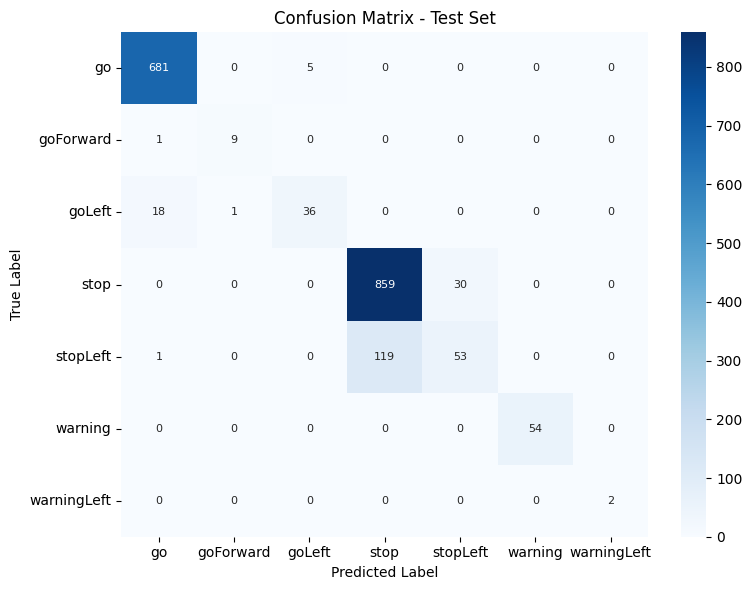

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
y_pred = np.argmax(model.predict(X_test, verbose=1), axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues',
            annot_kws={"size": 8})
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
go


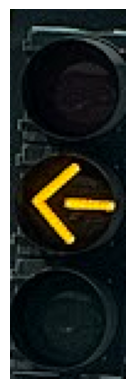

In [ ]:
#test a single image
from google.colab import files

uploaded = files.upload()
img = Image.open("test3.png").convert("RGB")
plt.imshow(img)
plt.axis("off")
img = img.resize((64, 64))

img_array = tf.keras.utils.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)

class_names = [
    "go",
    "goForward",
    "goLeft",
    "stop",
    "stopLeft",
    "warning",
    "warningLeft"
]

predicted_index = np.argmax(prediction)

print(class_names[predicted_index])

In [ ]:
model.save("/content/drive/MyDrive/AI_final_project/traffic_light_modelFINAL.keras") #save to google drive for future

In [ ]:
# Write app.py
with open("app.py", "w") as f:
    f.write("""
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

model = load_model("traffic_light_model.keras")

class_names = [
    "go",
    "goForward",
    "goLeft",
    "stop",
    "stopLeft",
    "warning",
    "warningLeft"
]

def predict(image):
    img = Image.fromarray(image).resize((64, 64))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)[0]
    return {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

demo = gr.Interface(fn=predict, inputs=gr.Image(), outputs=gr.Label(num_top_classes=3),
                    title="Traffic Light Detector")
demo.launch()
""")

# Write requirements.txt
with open("requirements.txt", "w") as f:
    f.write("tensorflow\ngradio\nnumpy\npillow\n")

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

# Upload app.py
api.upload_file(
    path_or_fileobj="app.py",
    path_in_repo="app.py",
    repo_id="jphappy/Traffic_light_detection",
    repo_type="space"
)

# Upload requirements.txt
api.upload_file(
    path_or_fileobj="requirements.txt",
    path_in_repo="requirements.txt",
    repo_id="jphappy/Traffic_light_detection",
    repo_type="space"
)

# Upload the model from your Google Drive
api.upload_file(
    path_or_fileobj="/content/drive/MyDrive/AI_final_project/traffic_light_modelFINAL.keras",
    path_in_repo="traffic_light_modelFINAL.keras",
    repo_id="jphappy/Traffic_light_detection",
    repo_type="space"
)

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ic_light_modelFINAL.keras:   2%|2         |  537kB / 25.5MB            

CommitInfo(commit_url='https://huggingface.co/spaces/jphappy/Traffic_light_detection/commit/ae0a23aea158a67835f8840b2cac1cd418397217', commit_message='Upload traffic_light_modelFINAL.keras with huggingface_hub', commit_description='', oid='ae0a23aea158a67835f8840b2cac1cd418397217', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/jphappy/Traffic_light_detection', endpoint='https://huggingface.co', repo_type='space', repo_id='jphappy/Traffic_light_detection'), pr_revision=None, pr_num=None)